In [76]:
import pandas as pd
input_data = 'data/studentdata.csv'
df = pd.read_csv(input_data, sep=';')
df

,Unnamed: 0,Deutsche,Deutsche.1,Deutsche.2,Deutsche.3,Deutsche.4,Deutsche.5,Deutsche.6,Deutsche.7,Ausländer,Ausländer.1,Ausländer.2,Ausländer.3,Ausländer.4,Ausländer.5,Ausländer.6,Ausländer.7
0,NaN,männlich,männlich,männlich,männlich,weiblich,weiblich,weiblich,weiblich,männlich,männlich,männlich,männlich,weiblich,weiblich,weiblich,weiblich
1,NaN,Bestandene Prüfung,Bestandene Prüfung,Nichtbestandene Prüfung,Nichtbestandene Prüfung,Bestandene Prüfung,Bestandene Prüfung,Nichtbestandene Prüfung,Nichtbestandene Prüfung,Bestandene Prüfung,Bestandene Prüfung,Nichtbestandene Prüfung,Nichtbestandene Prüfung,Bestandene Prüfung,Bestandene Prüfung,Nichtbestandene Prüfung,Nichtbestandene Prüfung
2,1999.0,118454,e,1641,e,91484,e,921,e,6851,e,125,e,4907,e,67,e
3,2000.0,111000,e,1541,e,90682,e,951,e,7396,e,153,e,5395,e,74,e
4,2001.0,104670,e,1552,e,89650,e,944,e,7792,e,154,e,6011,e,102,e
5,2002.0,102147,e,1414,e,91350,e,924,e,8404,e,182,e,6705,e,113,e
6,2003.0,103379,e,1392,e,97803,e,751,e,9198,e,146,e,7766,e,103,e
7,2004.0,107806,e,1503,e,103547,e,976,e,10581,e,200,e,9006,e,121,e
8,2005.0,114996,e,1309,e,113754,e,984,e,12515,e,214,e,11217,e,163,e
9,2006.0,118359,e,1532,e,121374,e,900,e,13276,e,287,e,12695,e,181,e


In [ ]:
df = pd.read_csv(input_data)

In [32]:
import sqlite3

# Establish a connection to an SQLite database
conn = sqlite3.connect("my_database.db")

# Read data from a table
df.to_sql("my_table", conn, if_exists="replace", index=False)
df = pd.read_sql("SELECT * FROM my_table", conn)

In [33]:
outfile_csv = "data/studentdata_out.csv"
df.to_csv(outfile_csv, index=False)

In [34]:
outfile_json = "data/studentdata_out.json"
df.to_json(outfile_json)

In [35]:
outfile_txt = "data/studentdata_out.txt"
df.to_csv(outfile_txt, header=df.columns, index=None, sep=';')

In [36]:
df.to_csv(outfile_csv, index=False)

In [37]:
df.head()

,;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer
0,;männlich;männlich;männlich;männlich;weiblich;...
1,;Bestandene Prüfung;Bestandene Prüfung;Nichtbe...
2,1999;118454;e;1641;e;91484;e;921;e;6851;e;125;...
3,2000;111000;e;1541;e;90682;e;951;e;7396;e;153;...
4,2001;104670;e;1552;e;89650;e;944;e;7792;e;154;...


In [38]:
df.tail(n = 10)

,;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer
18,2015;216616;e;12233;e;218538;e;5194;e;23303;e;...
19,2016;217922;e;11749;e;224644;e;5169;e;24852;e;...
20,2017;220222;e;12120;e;228779;e;5645;e;26474;e;...
21,2018;216217;e;13672;e;227458;e;6504;e;27575;e;...
22,2019;216973;e;14525;e;235306;e;7264;e;30664;e;...
23,2020;200355;e;9127;e;218888;e;4838;e;29798;e;1...
24,2021;210903;e;4309;e;241594;e;2460;e;33257;e;1...
25,2022;204436;e;5257;e;233200;e;2806;e;35255;e;1...
26,2023;199625;e;10434;e;232158;e;5329;e;37056;e;...
27,2024;200459;e;11756;e;236075;e;6497;e;39551;e;...


In [39]:
df.describe()

,;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer
count,28
unique,28
top,;männlich;männlich;männlich;männlich;weiblich;...
freq,1


In [40]:
df.describe(percentiles=[0.3, 0.5, 0.7])

,;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer
count,28
unique,28
top,;männlich;männlich;männlich;männlich;weiblich;...
freq,1


In [41]:
df.describe(exclude=[int])

,;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer
count,28
unique,28
top,;männlich;männlich;männlich;männlich;weiblich;...
freq,1


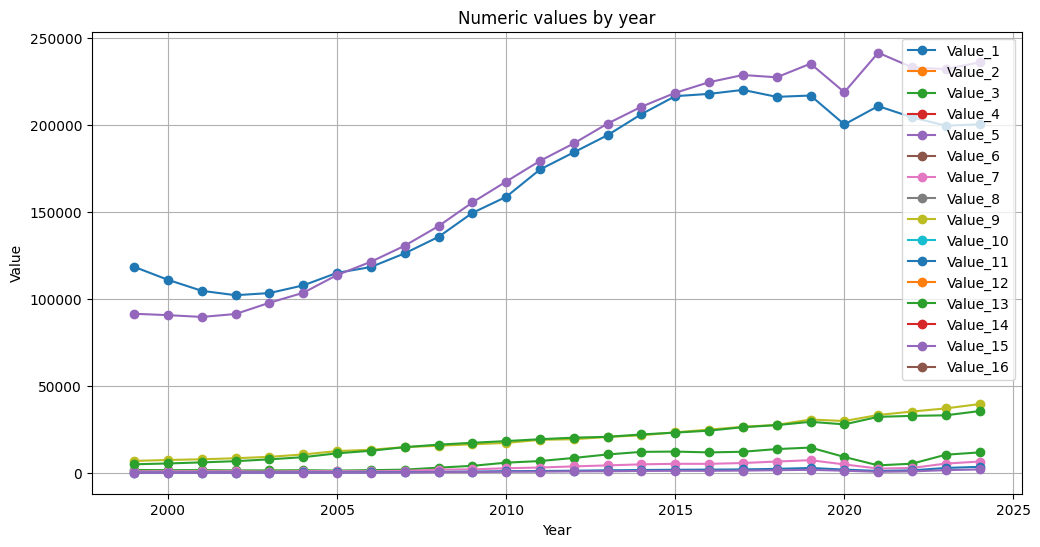

In [42]:
import matplotlib.pyplot as plt

plot_df = df.iloc[2:].copy()
plot_df = plot_df.rename(columns={'Unnamed: 0': 'Year'})
plot_df = plot_df.iloc[:, 0].str.split(';', expand=True)
plot_df.columns = ['Year'] + [f'Value_{i}' for i in range(1, plot_df.shape[1])]
plot_df['Year'] = pd.to_numeric(plot_df['Year'], errors='coerce')

for col in plot_df.columns.drop('Year'):
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

plot_df = plot_df.set_index('Year')
numeric_df = plot_df.select_dtypes(include='number')

numeric_df.plot(figsize=(12, 6), marker='o')
plt.title('Numeric values by year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid(True)
plt.legend(loc='best')

In [47]:
df.head()

,;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer
0,;männlich;männlich;männlich;männlich;weiblich;...
1,;Bestandene Prüfung;Bestandene Prüfung;Nichtbe...
2,1999;118454;e;1641;e;91484;e;921;e;6851;e;125;...
3,2000;111000;e;1541;e;90682;e;951;e;7396;e;153;...
4,2001;104670;e;1552;e;89650;e;944;e;7792;e;154;...


This kkk

In [50]:
print(df.shape)
print(df.head())

(28, 1)
  ;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Deutsche;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer;Ausländer
0  ;männlich;männlich;männlich;männlich;weiblich;...                                                                                                      
1  ;Bestandene Prüfung;Bestandene Prüfung;Nichtbe...                                                                                                      
2  1999;118454;e;1641;e;91484;e;921;e;6851;e;125;...                                                                                                      
3  2000;111000;e;1541;e;90682;e;951;e;7396;e;153;...                                                                                                      
4  2001;104670;e;1552;e;89650;e;944;e;7792;e;154;...                                                                                                      


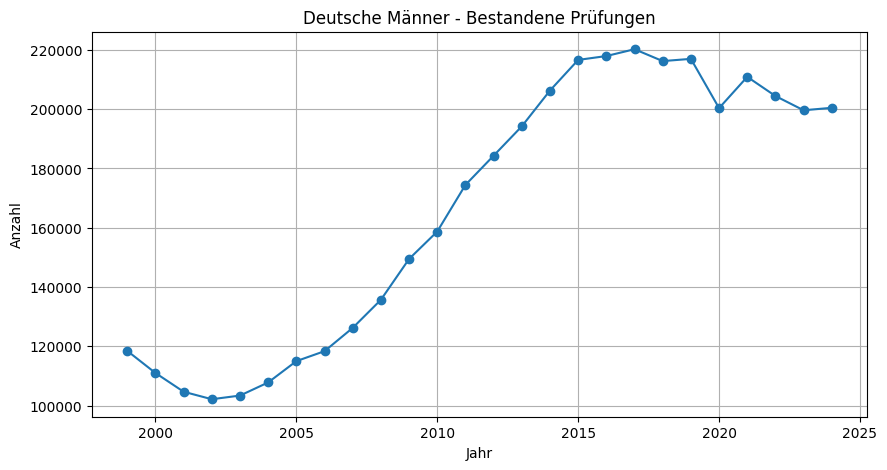

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv(input_data, sep=";")
df.columns = df.columns.str.strip()

plt.figure(figsize=(10,5))
plt.plot(df.iloc[2:, 0], df.iloc[2:, 1].astype(int), marker="o")
#plt.plot(df.index[2:], df.iloc[2:, 0].astype(int), marker="o")
plt.title("Deutsche Männer - Bestandene Prüfungen")
plt.xlabel("Jahr")
plt.ylabel("Anzahl")
plt.grid()
plt.show()

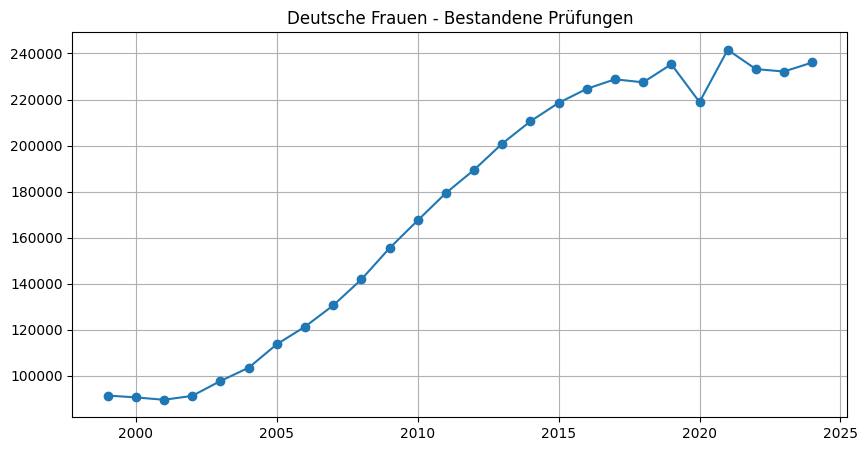

In [56]:
plt.figure(figsize=(10,5))
plt.plot(df.iloc[2:, 0], df.iloc[2:, 5].astype(int), marker="o")
plt.title("Deutsche Frauen - Bestandene Prüfungen")
plt.grid()
plt.show()

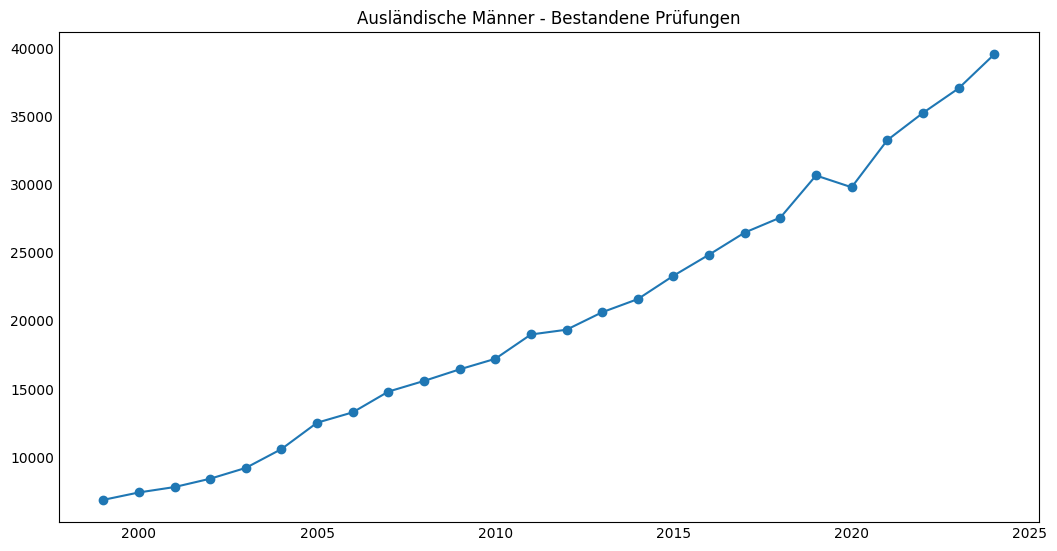

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df.iloc[2:, 0], df.iloc[2:, 9].astype(int), marker="o")
plt.title("Ausländische Männer - Bestandene Prüfungen")
plt.grid()
plt.show()

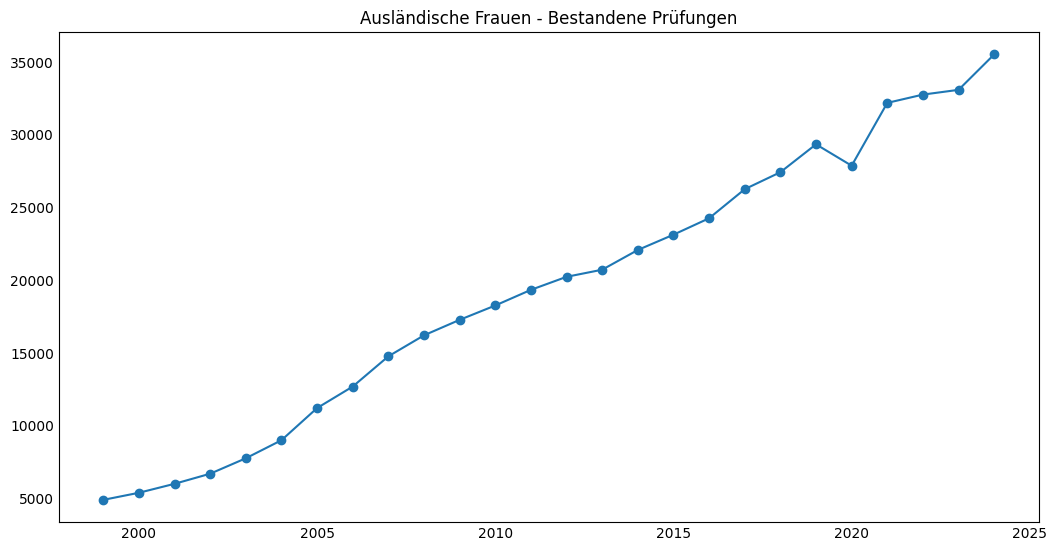

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df.iloc[2:, 0], df.iloc[2:, 13].astype(int), marker="o")
plt.title("Ausländische Frauen - Bestandene Prüfungen")
plt.grid()
plt.show()

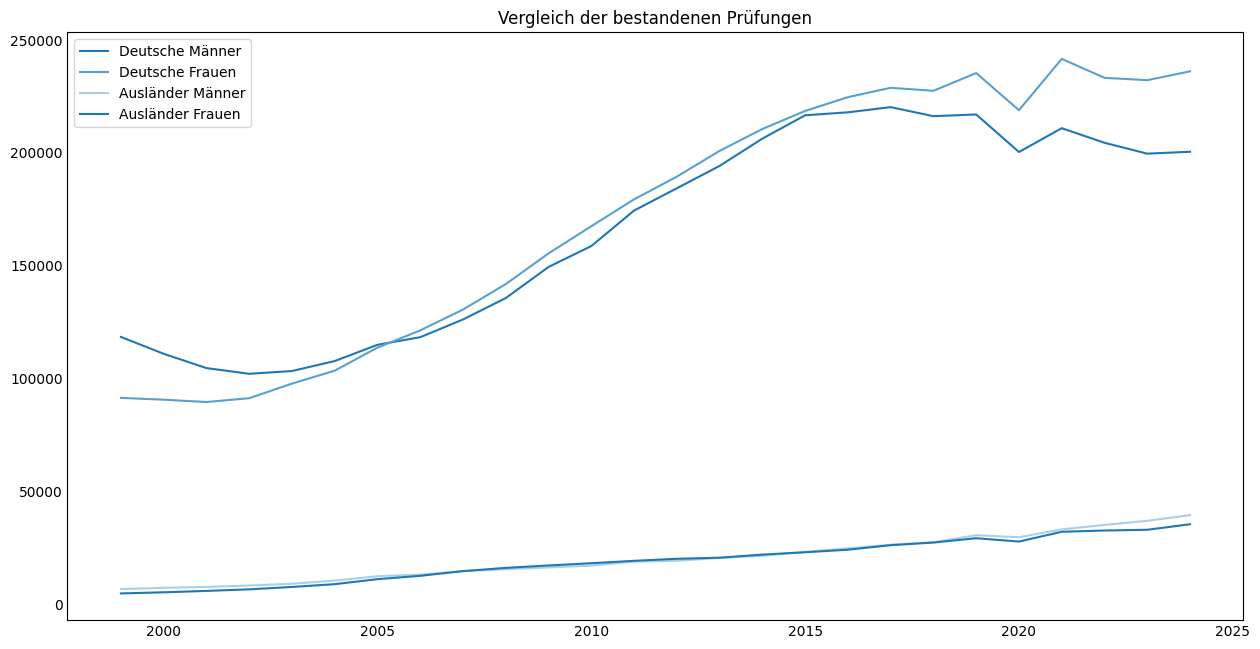

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df.iloc[2:,0], df.iloc[2:,1].astype(int), label="Deutsche Männer")
plt.plot(df.iloc[2:,0], df.iloc[2:,5].astype(int), label="Deutsche Frauen")
plt.plot(df.iloc[2:,0], df.iloc[2:,9].astype(int), label="Ausländer Männer")
plt.plot(df.iloc[2:,0], df.iloc[2:,13].astype(int), label="Ausländer Frauen")

plt.legend()
plt.grid()
plt.title("Vergleich der bestandenen Prüfungen")
plt.show()

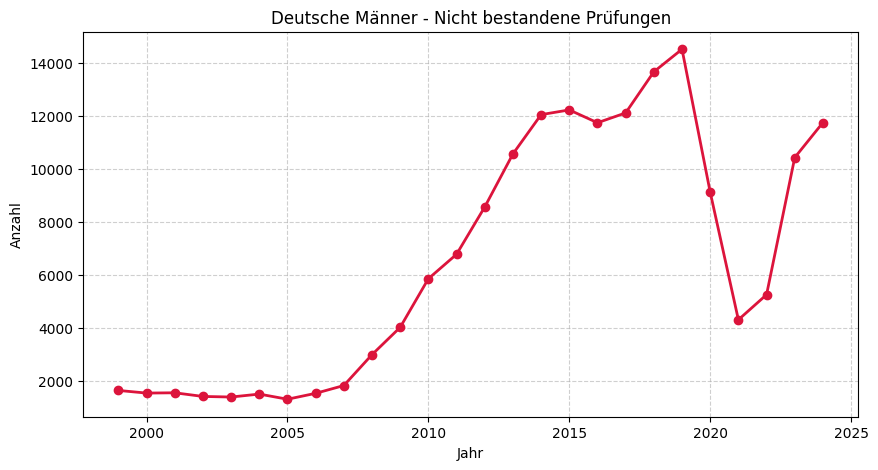

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data with the correct semicolon separator
df = pd.read_csv(input_data, sep=";")
df.columns = df.columns.str.strip()

# 2. Extract the data
# Column 0 = Years (1999, 2000...)
# Column 3 = Deutsche -> männlich -> Nicht bestandene Prüfung (1641, 1541...)
years = df.iloc[2:, 0]
values = df.iloc[2:, 3].astype(int) 

# 3. Plotting
plt.figure(figsize=(10, 5))
plt.plot(years, values, marker="o", color="crimson", linewidth=2) # Changed color to red for "Nicht bestanden"

plt.title("Deutsche Männer - Nicht bestandene Prüfungen")
plt.xlabel("Jahr")
plt.ylabel("Anzahl")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

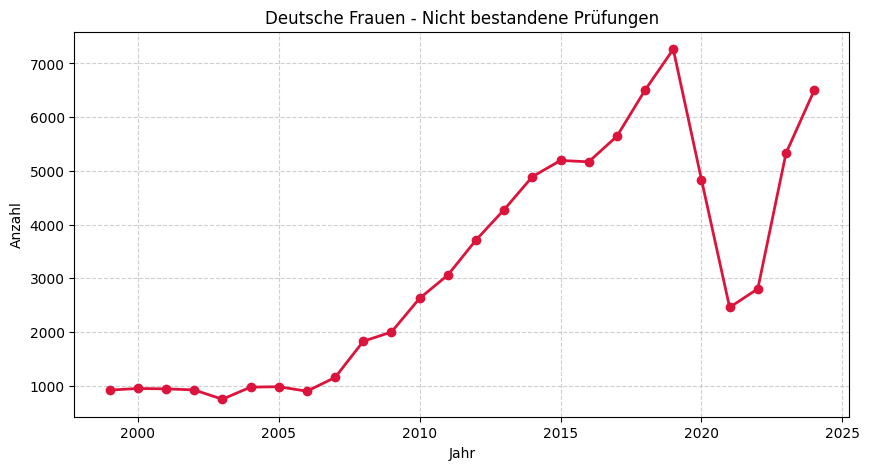

In [69]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(input_data, sep=";")
df.columns = df.columns.str.strip()


years = df.iloc[2:, 0]
failed_women = df.iloc[2:, 7].astype(int)  


plt.figure(figsize=(10, 5))
plt.plot(years, failed_women, marker="o", color="crimson", linewidth=2)

plt.title("Deutsche Frauen - Nicht bestandene Prüfungen")
plt.xlabel("Jahr")
plt.ylabel("Anzahl")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

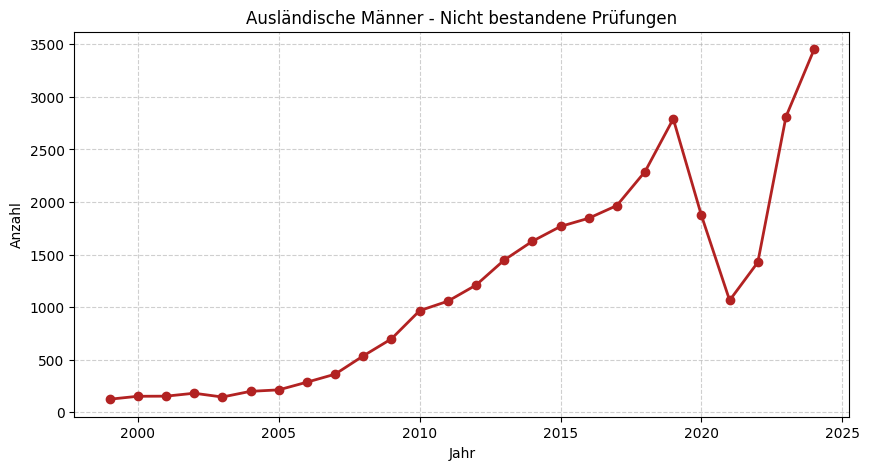

In [73]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(input_data, sep=";")
df.columns = df.columns.str.strip()


years = df.iloc[2:, 0]
failed_foreign_men = df.iloc[2:, 11].astype(int)  


plt.figure(figsize=(10, 5))
plt.plot(years, failed_foreign_men, marker="o", color="firebrick", linewidth=2)

plt.title("Ausländische Männer - Nicht bestandene Prüfungen")
plt.xlabel("Jahr")
plt.ylabel("Anzahl")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

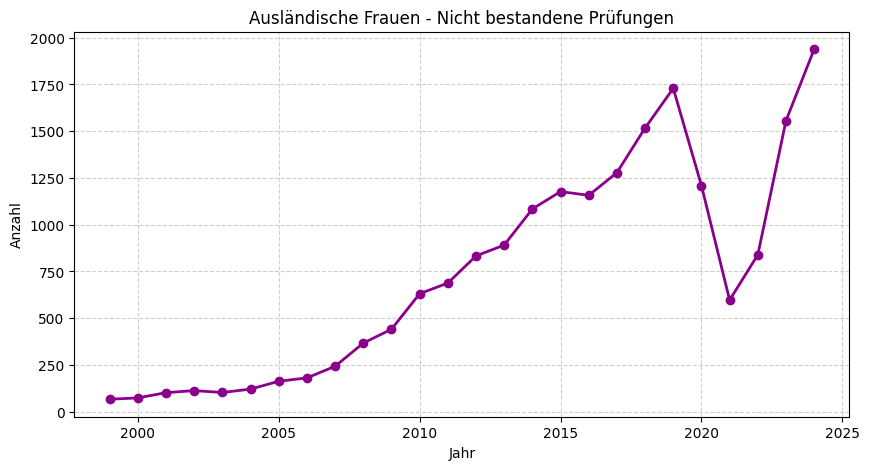

In [74]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(input_data, sep=";")
df.columns = df.columns.str.strip()


years = df.iloc[2:, 0]
failed_foreign_women = df.iloc[2:, 15].astype(int)  


plt.figure(figsize=(10, 5))
plt.plot(years, failed_foreign_women, marker="o", color="darkmagenta", linewidth=2)

plt.title("Ausländische Frauen - Nicht bestandene Prüfungen")
plt.xlabel("Jahr")
plt.ylabel("Anzahl")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

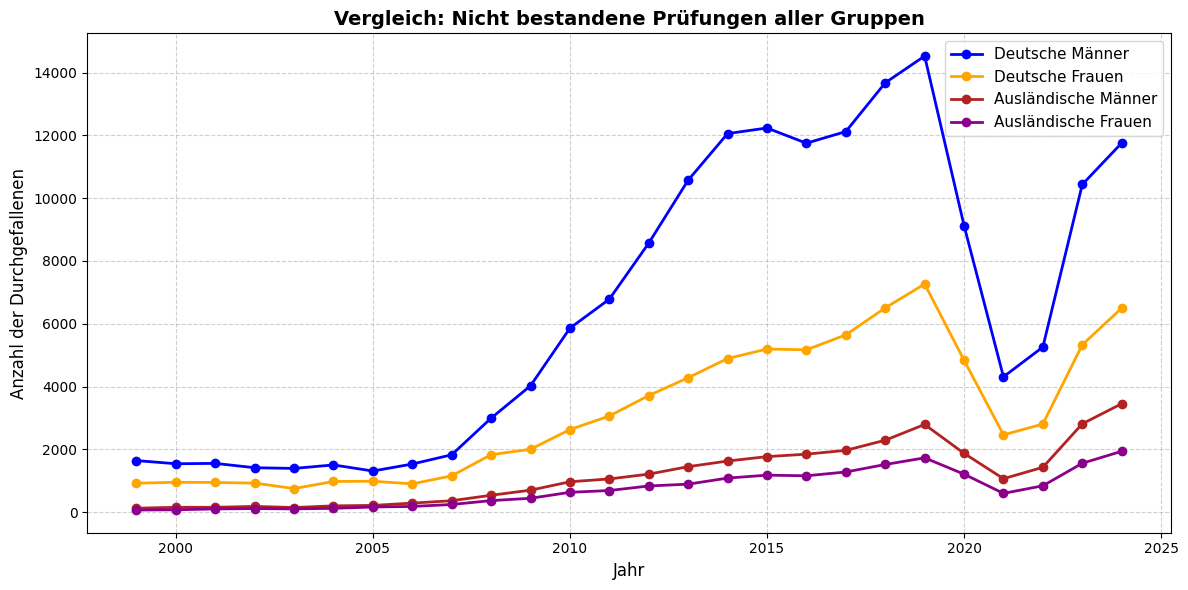

In [77]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(input_data, sep=";")
df.columns = df.columns.str.strip()


years = df.iloc[2:, 0]

failed_de_men = df.iloc[2:, 3].astype(int)       
failed_de_women = df.iloc[2:, 7].astype(int)     
failed_frgn_men = df.iloc[2:, 11].astype(int)    
failed_frgn_women = df.iloc[2:, 15].astype(int)  


plt.figure(figsize=(12, 6))


plt.plot(years, failed_de_men, marker="o", color="blue", label="Deutsche Männer", linewidth=2)
plt.plot(years, failed_de_women, marker="o", color="orange", label="Deutsche Frauen", linewidth=2)
plt.plot(years, failed_frgn_men, marker="o", color="firebrick", label="Ausländische Männer", linewidth=2)
plt.plot(years, failed_frgn_women, marker="o", color="darkmagenta", label="Ausländische Frauen", linewidth=2)


plt.title("Vergleich: Nicht bestandene Prüfungen aller Gruppen", fontsize=14, fontweight='bold')
plt.xlabel("Jahr", fontsize=12)
plt.ylabel("Anzahl der Durchgefallenen", fontsize=12)


plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()